# Flickr8k — Data Exploration, Cleaning & Preparation

This notebook covers:
1. Loading and inspecting the Flickr8k dataset
2. Exploratory Data Analysis (EDA)
3. Caption cleaning (no tokenization — deferred to modelling notebook)
4. Train / Validation / Test split
5. Saving cleaned data for the modelling stage

**What is NOT done here:** tokenization, vocabulary building, feature extraction — all deferred to the modelling notebook.

## 0. Imports & Configuration

In [1]:
import os
import re
import json
import random
import string
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Paths — adjust to your local directory structure ─────────────────────────
DATA_DIR        = Path("./data")                 # root dataset folder
IMAGES_DIR      = DATA_DIR / "Images"            # all 8,000 images
CAPTIONS_FILE   = DATA_DIR / "captions.txt"      # image,caption pairs
OUTPUT_DIR      = Path("data/prepared")          # cleaned outputs go here
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Plot style ───────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("All imports successful.")
print(f"Images directory : {IMAGES_DIR}")
print(f"Captions file    : {CAPTIONS_FILE}")
print(f"Output directory : {OUTPUT_DIR}")

All imports successful.
Images directory : data\Images
Captions file    : data\captions.txt
Output directory : data\prepared


## 1. Load Raw Captions

The standard Flickr8k `captions.txt` format is:
```
image,caption
1000268201_693b08cb0e.jpg,A child in a pink dress ...
```
Each image has **5 captions**, giving 40,000 rows total.

In [2]:
df_raw = pd.read_csv(CAPTIONS_FILE, sep=",", header=0)
df_raw.columns = ["image", "caption"]

# Strip accidental whitespace
df_raw["image"]   = df_raw["image"].str.strip()
df_raw["caption"] = df_raw["caption"].str.strip()

print(f"Total rows          : {len(df_raw):,}")
print(f"Unique images       : {df_raw['image'].nunique():,}")
print(f"Captions per image  : {len(df_raw) / df_raw['image'].nunique():.1f}")
df_raw.head(10)

Total rows          : 40,455
Unique images       : 8,091
Captions per image  : 5.0


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
6,1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with...
7,1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots a...
8,1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each o...
9,1001773457_577c3a7d70.jpg,Two dogs on pavement moving toward each other .


## 2. Basic Dataset Inspection

In [3]:
print("── Shape ──────────────────────────────")
print(df_raw.shape)

print("\n── Data types ─────────────────────────")
print(df_raw.dtypes)

print("\n── Missing values ──────────────────────")
print(df_raw.isnull().sum())

print("\n── Duplicate rows ──────────────────────")
print(f"Exact duplicate rows: {df_raw.duplicated().sum()}")

print("\n── Sample captions for one image ───────")
sample_img = df_raw["image"].iloc[0]
print(f"Image: {sample_img}")
for cap in df_raw[df_raw["image"] == sample_img]["caption"].values:
    print(f"  • {cap}")

── Shape ──────────────────────────────
(40455, 2)

── Data types ─────────────────────────
image      object
caption    object
dtype: object

── Missing values ──────────────────────
image      0
caption    0
dtype: int64

── Duplicate rows ──────────────────────
Exact duplicate rows: 10

── Sample captions for one image ───────
Image: 1000268201_693b08cb0e.jpg
  • A child in a pink dress is climbing up a set of stairs in an entry way .
  • A girl going into a wooden building .
  • A little girl climbing into a wooden playhouse .
  • A little girl climbing the stairs to her playhouse .
  • A little girl in a pink dress going into a wooden cabin .


### 2.1 Delete the Duplicate Rows

In [5]:
df_raw = df_raw.drop_duplicates()

## 3. Verify Image Files on Disk

In [6]:
available_images = set(os.listdir(IMAGES_DIR))
referenced_images = set(df_raw["image"].unique())

missing_from_disk    = referenced_images - available_images
unreferenced_on_disk = available_images  - referenced_images

print(f"Images on disk                  : {len(available_images):,}")
print(f"Images referenced in captions   : {len(referenced_images):,}")
print(f"Referenced but missing on disk  : {len(missing_from_disk)}")
print(f"On disk but not in captions     : {len(unreferenced_on_disk)}")

if missing_from_disk:
    print("\nMissing files:")
    for f in list(missing_from_disk)[:10]:
        print(f"  {f}")

# Keep only rows whose image file actually exists
df = df_raw[df_raw["image"].isin(available_images)].copy()
print(f"\nRows after disk verification: {len(df):,}")

Images on disk                  : 8,091
Images referenced in captions   : 8,091
Referenced but missing on disk  : 0
On disk but not in captions     : 0

Rows after disk verification: 40,445


## 4. Exploratory Data Analysis (EDA)

### 4.1 Sample Images

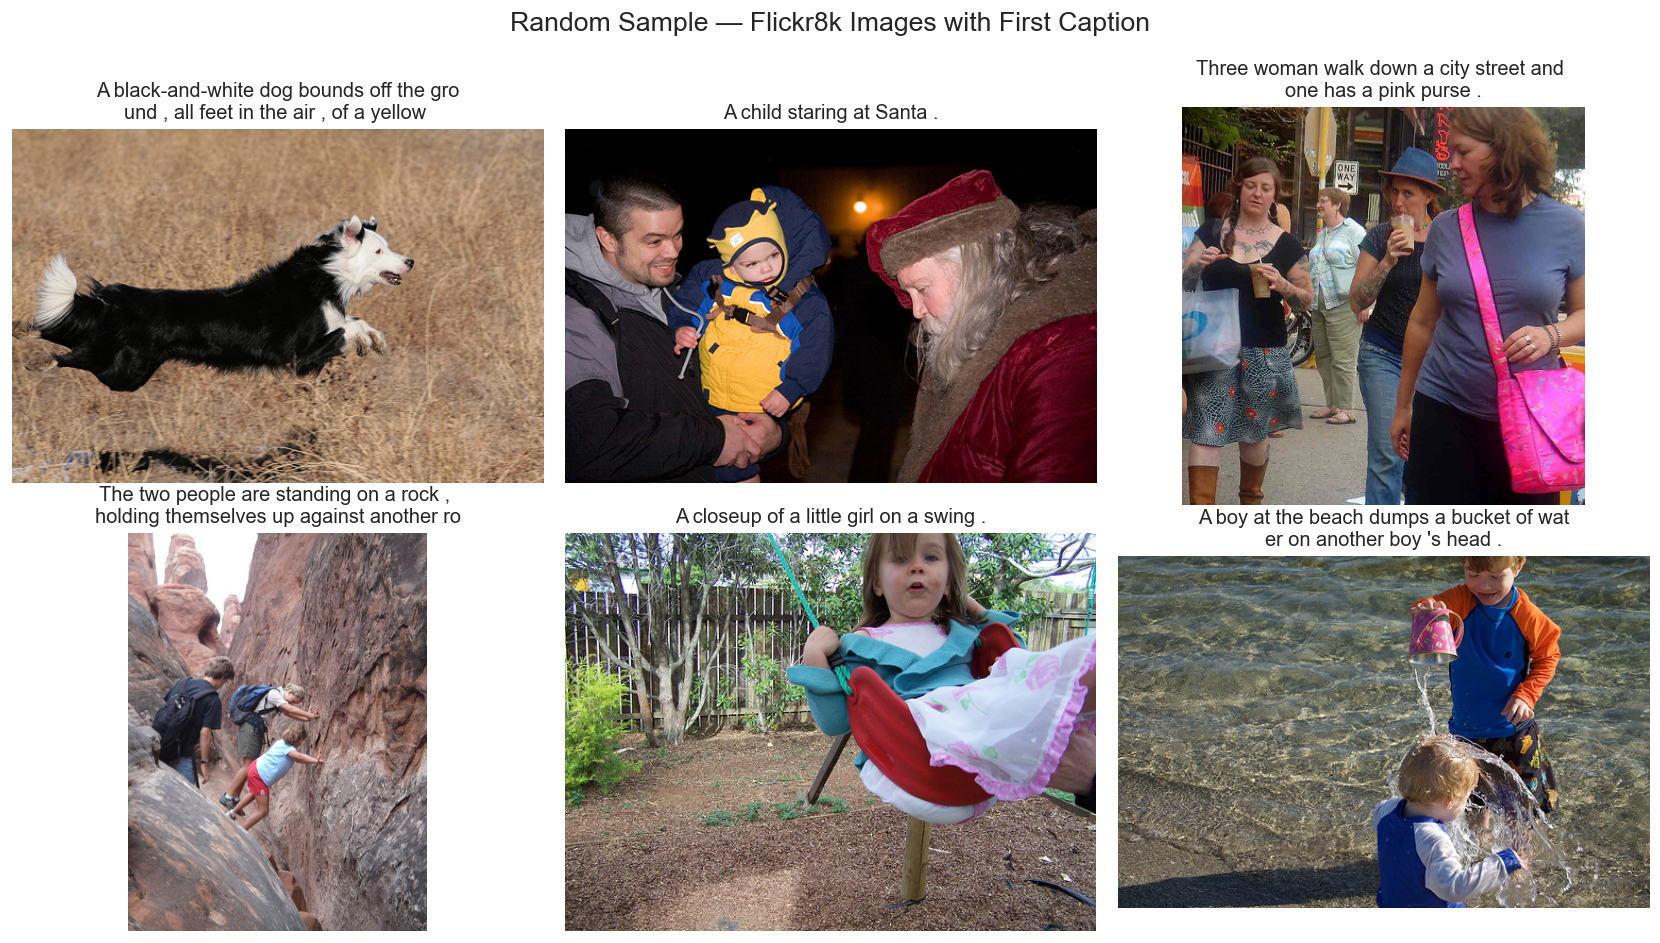

In [9]:
sample_images = df["image"].drop_duplicates().sample(6, random_state=SEED).tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, img_name in zip(axes.flat, sample_images):
    img = mpimg.imread(IMAGES_DIR / img_name)
    ax.imshow(img)
    # Show first caption below image
    cap = df[df["image"] == img_name]["caption"].values[0]
    ax.set_title("\n".join([cap[i:i+40] for i in range(0, min(80, len(cap)), 40)]),
                 fontsize=12)
    ax.axis("off")
plt.suptitle("Random Sample — Flickr8k Images with First Caption", fontsize=16)
plt.tight_layout()
plt.show()

### 4.2 Caption Length Distribution (raw, in words)

Caption length statistics (words):
count    40445.00
mean        11.78
std          3.89
min          1.00
25%          9.00
50%         11.00
75%         14.00
max         38.00
Name: word_count, dtype: float64


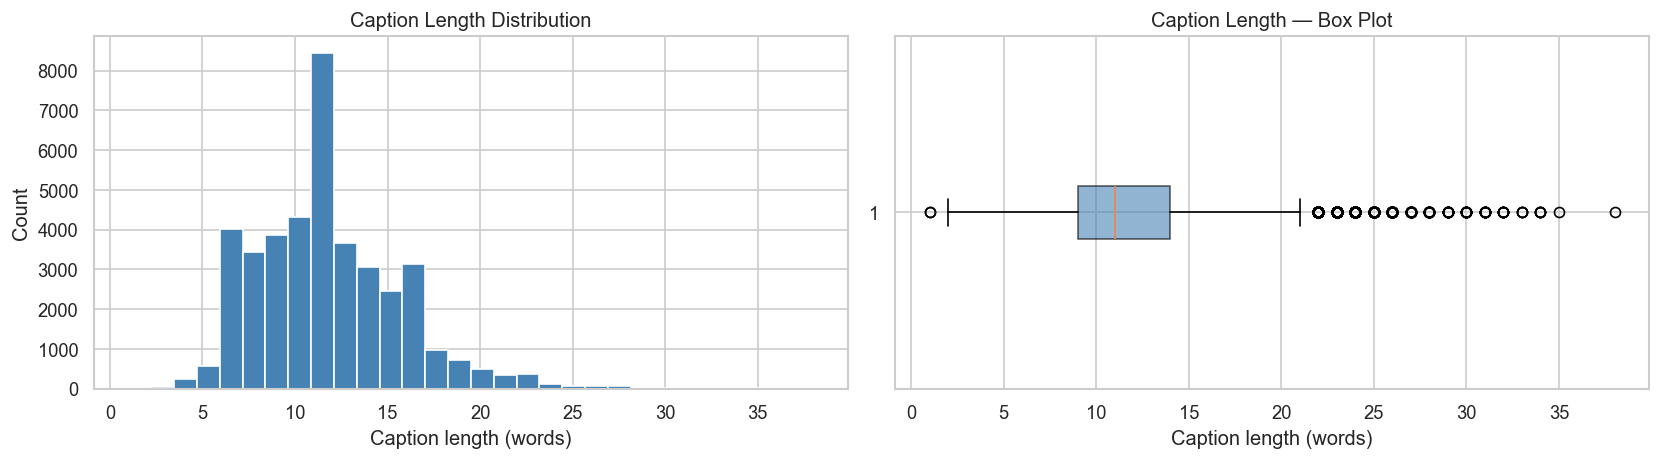

  90th percentile: 17 words
  95th percentile: 19 words
  99th percentile: 23 words


In [10]:
df["word_count"] = df["caption"].apply(lambda x: len(x.split()))

print("Caption length statistics (words):")
print(df["word_count"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df["word_count"], bins=30, edgecolor="white", color="steelblue")
axes[0].set_xlabel("Caption length (words)")
axes[0].set_ylabel("Count")
axes[0].set_title("Caption Length Distribution")

# Box plot
axes[1].boxplot(df["word_count"], vert=False, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_xlabel("Caption length (words)")
axes[1].set_title("Caption Length — Box Plot")

plt.tight_layout()
plt.show()

# Percentile thresholds — useful for deciding max_seq_len later
for p in [90, 95, 99]:
    print(f"  {p}th percentile: {np.percentile(df['word_count'], p):.0f} words")

#### 4.2.1 Show captions of 1 word

In [18]:
df[df['word_count'] == 1]

,image,caption,word_count
9305,2428275562_4bde2bc5ea.jpg,A,1
33360,3640443200_b8066f37f6.jpg,a,1


#### 4.2.2 Delete Captions of 1 Word

In [30]:
df = df[df['word_count'] > 1]

### 4.3 Character-Level Caption Length

Caption length statistics (characters):
count    40443.00
mean        55.14
std         18.84
min          7.00
25%         42.00
50%         53.00
75%         66.00
max        199.00
Name: char_count, dtype: float64


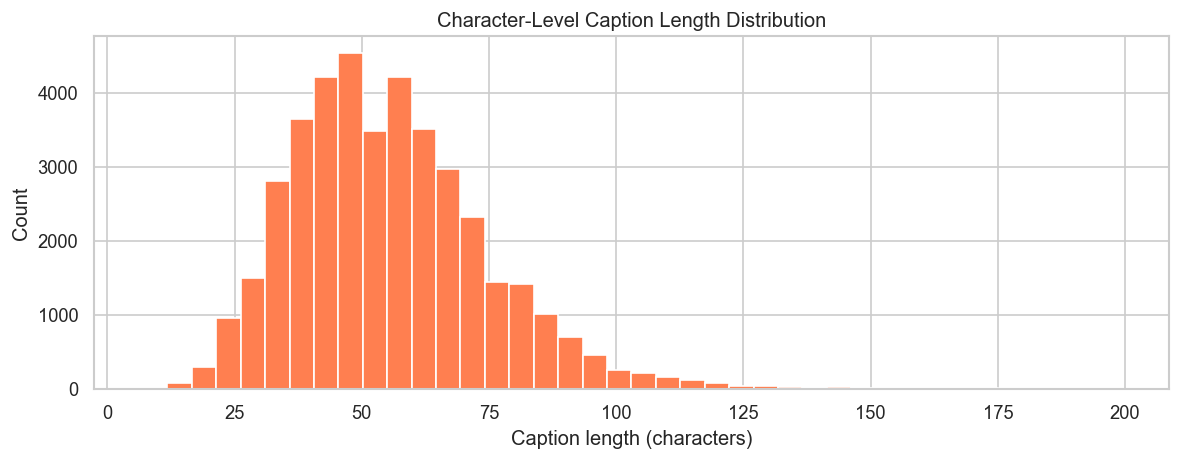

In [32]:
df["char_count"] = df["caption"].apply(len)

print("Caption length statistics (characters):")
print(df["char_count"].describe().round(2))

plt.figure(figsize=(10, 4))
plt.hist(df["char_count"], bins=40, edgecolor="white", color="coral")
plt.xlabel("Caption length (characters)")
plt.ylabel("Count")
plt.title("Character-Level Caption Length Distribution")
plt.tight_layout()
plt.show()

### 4.4 Most Frequent Words (raw captions)

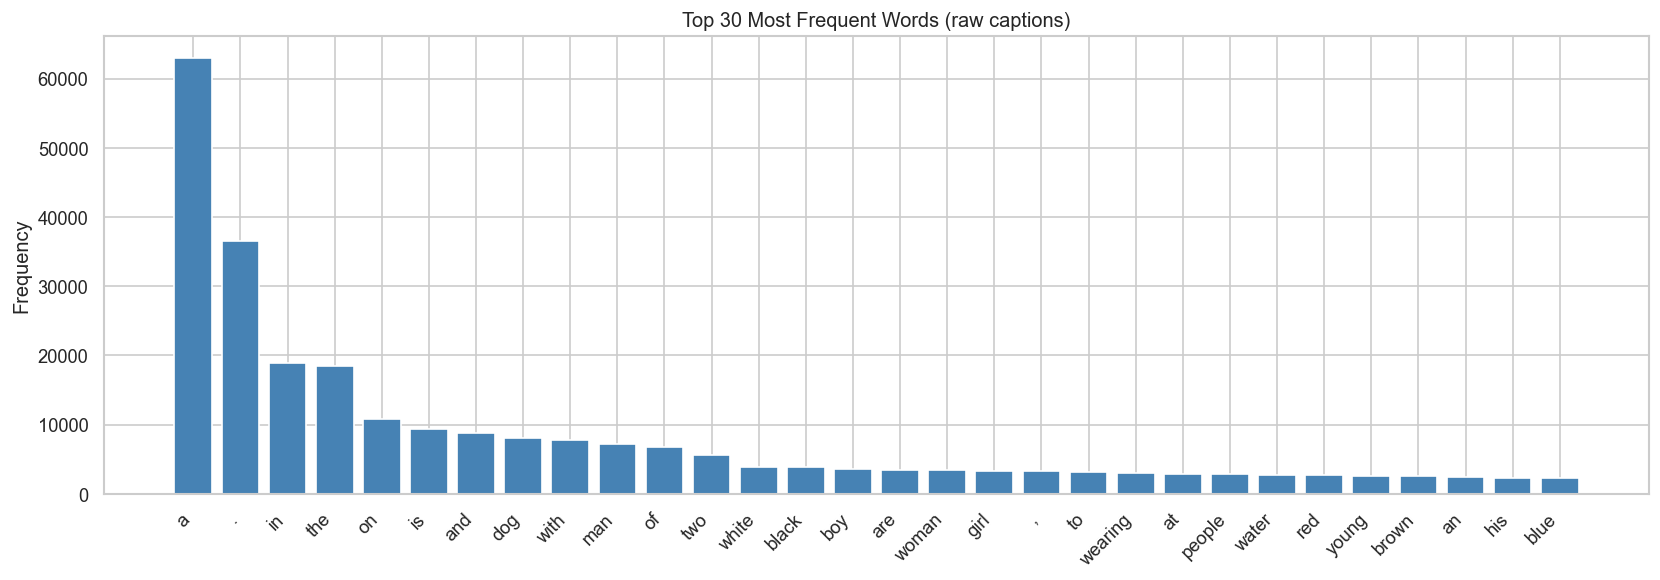


Total unique raw words : 8,918
Total word tokens      : 476,575


In [35]:
all_words = " ".join(df["caption"].tolist()).lower().split()
word_freq  = Counter(all_words)

top_n = 30
top_words, top_counts = zip(*word_freq.most_common(top_n))

plt.figure(figsize=(14, 5))
plt.bar(top_words, top_counts, color="steelblue", edgecolor="white")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Frequency")
plt.title(f"Top {top_n} Most Frequent Words (raw captions)")
plt.tight_layout()
plt.show()

print(f"\nTotal unique raw words : {len(word_freq):,}")
print(f"Total word tokens      : {sum(word_freq.values()):,}")

### 4.5 Image Dimension Analysis

Width  — mean: 458  min: 255  max: 500
Height — mean: 397  min: 178  max: 500


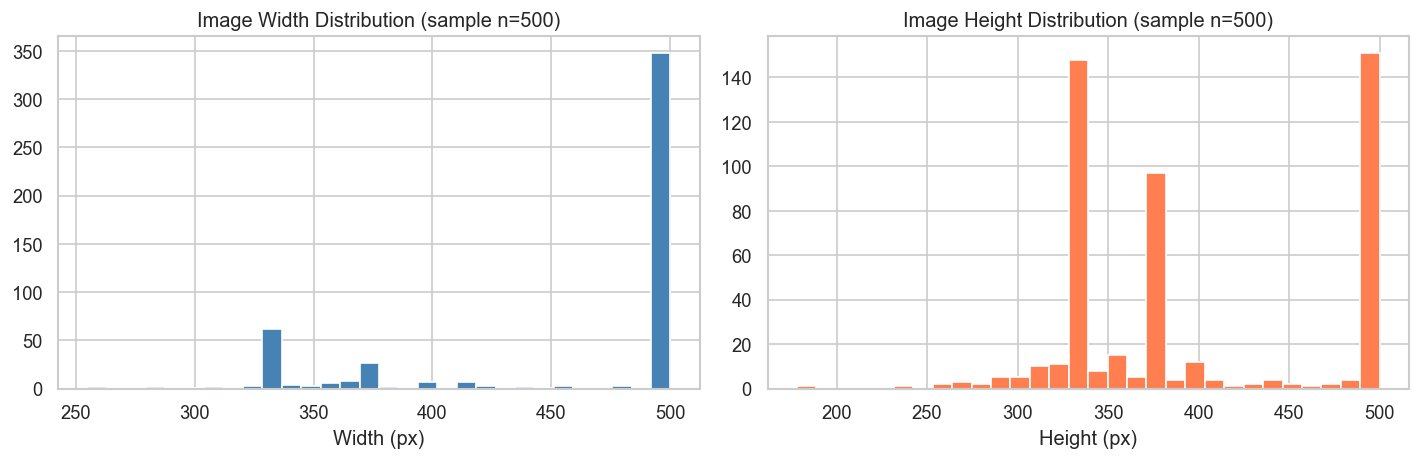

In [37]:
# Sample 500 images to inspect dimensions (reading all 8k is slow)
sample_imgs = df["image"].drop_duplicates().sample(500, random_state=SEED)

widths, heights = [], []
for img_name in sample_imgs:
    with Image.open(IMAGES_DIR / img_name) as im:
        w, h = im.size
        widths.append(w)
        heights.append(h)

print(f"Width  — mean: {np.mean(widths):.0f}  min: {np.min(widths)}  max: {np.max(widths)}")
print(f"Height — mean: {np.mean(heights):.0f}  min: {np.min(heights)}  max: {np.max(heights)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Image Width Distribution (sample n=500)")
axes[0].set_xlabel("Width (px)")

axes[1].hist(heights, bins=30, color="coral", edgecolor="white")
axes[1].set_title("Image Height Distribution (sample n=500)")
axes[1].set_xlabel("Height (px)")

plt.tight_layout()
plt.show()

### 4.6 Captions Per Image Sanity Check

In [38]:
caps_per_image = df.groupby("image")["caption"].count()
print("Captions per image distribution:")
print(caps_per_image.value_counts().sort_index())

# Flag images that do not have exactly 5 captions
anomalies = caps_per_image[caps_per_image != 5]
if len(anomalies) > 0:
    print(f"\n⚠ Images without exactly 5 captions: {len(anomalies)}")
    print(anomalies)
else:
    print("\n✓ All images have exactly 5 captions.")

Captions per image distribution:
caption
4      12
5    8079
Name: count, dtype: int64

⚠ Images without exactly 5 captions: 12
image
2305437797_e6c3460190.jpg    4
2335619125_2e2034f2c3.jpg    4
2428275562_4bde2bc5ea.jpg    4
2441629086_52f68eb316.jpg    4
2737729252_b3fd9c05b1.jpg    4
3262075846_5695021d84.jpg    4
3337046794_296bd2c7e0.jpg    4
3355827928_c96c0c3e88.jpg    4
3552796830_2dd2aa9c2c.jpg    4
3640443200_b8066f37f6.jpg    4
3730457171_e66dde8c91.jpg    4
485741580_ab523fa657.jpg     4
Name: caption, dtype: int64


## 5. Caption Cleaning

Operations applied (tokenization is **not** done here — deferred to modelling notebook):

1. Lowercase everything
2. Remove punctuation
3. Collapse multiple whitespaces
4. Strip leading/trailing whitespace
5. Add `<START>` and `<END>` special tokens
6. Remove captions that are empty after cleaning
7. Remove captions with fewer than 2 words (degenerate)

In [ ]:
def clean_caption(text: str) -> str:
    """Clean a single caption string."""
    # 1. Lowercase
    text = text.lower()
    # 2. Remove punctuation (keep apostrophes for contractions optionally)
    text = re.sub(r"[^\w\s]", "", text)   # removes all non-word, non-space chars
    # 3. Remove digits standing alone (e.g. "2 dogs" → keep; rarely meaningful)
    #    Comment this out if you want to keep numbers
    text = re.sub(r"\b\d+\b", "", text)
    # 4. Collapse multiple spaces
    text = re.sub(r"\s+", " ", text)
    # 5. Strip
    text = text.strip()
    # 6. Add special tokens
    if text:
        text = "<START> " + text + " <END>"
    return text


df["caption_clean"] = df["caption"].apply(clean_caption)

# Show before / after side by side
print("Before vs After cleaning (first 5 rows):")
comparison = df[["image", "caption", "caption_clean"]].head(5)
for _, row in comparison.iterrows():
    print(f"  RAW   : {row['caption']}")
    print(f"  CLEAN : {row['caption_clean']}")
    print()

Before vs After cleaning (first 5 rows):
  RAW   : A child in a pink dress is climbing up a set of stairs in an entry way .
  CLEAN : <START> a child in a pink dress is climbing up a set of stairs in an entry way <END>

  RAW   : A girl going into a wooden building .
  CLEAN : <START> a girl going into a wooden building <END>

  RAW   : A little girl climbing into a wooden playhouse .
  CLEAN : <START> a little girl climbing into a wooden playhouse <END>

  RAW   : A little girl climbing the stairs to her playhouse .
  CLEAN : <START> a little girl climbing the stairs to her playhouse <END>

  RAW   : A little girl in a pink dress going into a wooden cabin .
  CLEAN : <START> a little girl in a pink dress going into a wooden cabin <END>



In [45]:
# Remove empty or degenerate captions after cleaning
before = len(df)
df = df[df["caption_clean"].str.len() > 0].copy()

# Word count of cleaned caption (excluding special tokens)
df["clean_word_count"] = df["caption_clean"].apply(
    lambda x: len(x.replace("<START>", "").replace("<END>", "").split())
)
df = df[df["clean_word_count"] >= 2].copy()

after = len(df)
print(f"Rows removed during cleaning : {before - after}")
print(f"Rows remaining               : {after:,}")

print("\nCleaned caption word count stats:")
print(df["clean_word_count"].describe().round(2))

Rows removed during cleaning : 0
Rows remaining               : 40,443

Cleaned caption word count stats:
count    40443.00
mean        10.79
std          3.76
min          2.00
25%          8.00
50%         10.00
75%         13.00
max         35.00
Name: clean_word_count, dtype: float64


### 5.1 Word Frequency After Cleaning

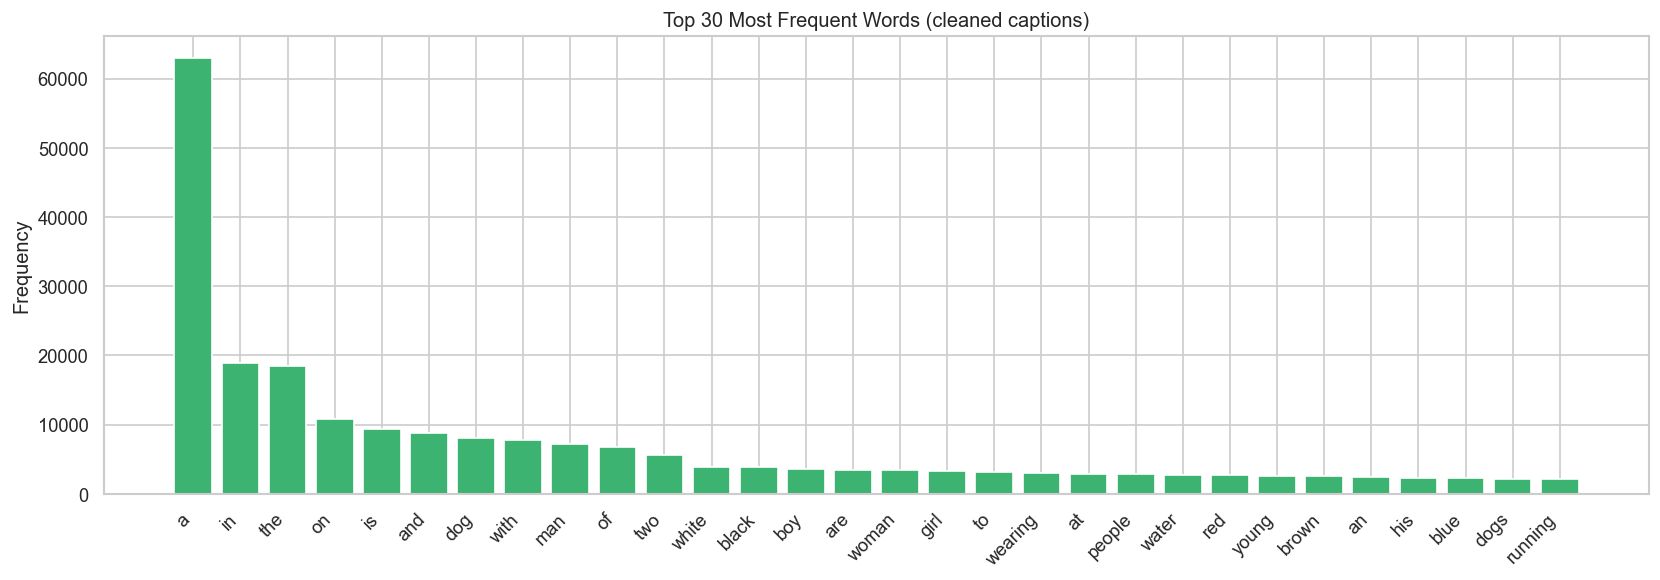

Unique words after cleaning : 8,783
  Words appearing >= 1x : 8,783 / 8,783  (100.0%)
  Words appearing >= 2x : 5,199 / 8,783  (59.2%)
  Words appearing >= 3x : 4,080 / 8,783  (46.5%)
  Words appearing >= 5x : 2,984 / 8,783  (34.0%)


In [48]:
# Exclude special tokens from frequency analysis
clean_text = " ".join(df["caption_clean"].tolist())
clean_text = clean_text.replace("<START>", "").replace("<END>", "")
clean_word_freq = Counter(clean_text.split())

top_n = 30
top_words, top_counts = zip(*clean_word_freq.most_common(top_n))

plt.figure(figsize=(14, 5))
plt.bar(top_words, top_counts, color="mediumseagreen", edgecolor="white")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Frequency")
plt.title(f"Top {top_n} Most Frequent Words (cleaned captions)")
plt.tight_layout()
plt.show()

print(f"Unique words after cleaning : {len(clean_word_freq):,}")

# Vocabulary coverage by frequency threshold
for threshold in [1, 2, 3, 5]:
    kept  = sum(1 for w, c in clean_word_freq.items() if c >= threshold)
    total = len(clean_word_freq)
    print(f"  Words appearing >= {threshold}x : {kept:,} / {total:,}  ({kept/total*100:.1f}%)")

### 5.2 Caption Length After Cleaning vs Before

C:\Users\CARNIVAL\AppData\Local\Temp\ipykernel_7060\3976306598.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df["word_count"], df["clean_word_count"]],


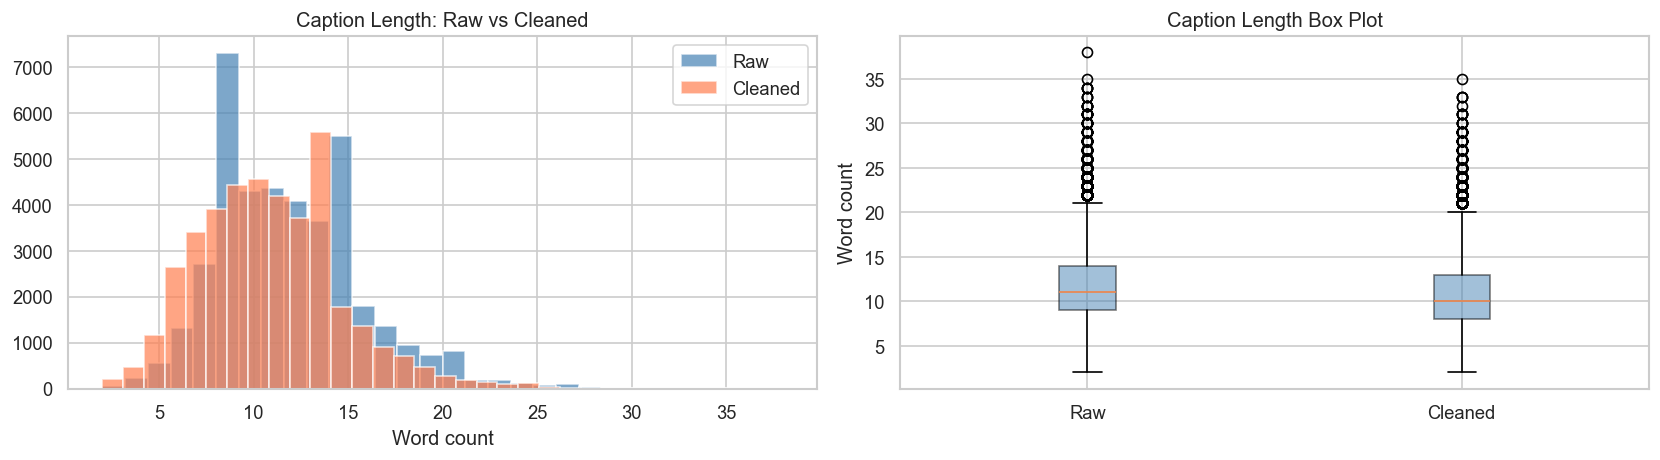

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["word_count"],       bins=30, color="steelblue", edgecolor="white", alpha=0.7, label="Raw")
axes[0].hist(df["clean_word_count"], bins=30, color="coral",     edgecolor="white", alpha=0.7, label="Cleaned")
axes[0].legend()
axes[0].set_xlabel("Word count")
axes[0].set_title("Caption Length: Raw vs Cleaned")

axes[1].boxplot([df["word_count"], df["clean_word_count"]],
                labels=["Raw", "Cleaned"], patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.5))
axes[1].set_ylabel("Word count")
axes[1].set_title("Caption Length Box Plot")

plt.tight_layout()
plt.show()

## 6. Train / Validation / Test Split

Standard Flickr8k splits applied **at the image level** (not row level) to prevent data leakage:
- Train : 7,000 images
- Val   : 500 images
- Test  : 500 images

We preserve all 5 captions per image in every split.

In [57]:
# ── Option A: use official Flickr8k split files if you have them ─────────────
# Uncomment the block below if you downloaded the official split .txt files
# from the Flickr8k dataset page.

# SPLIT_DIR = DATA_DIR / "splits"
# train_imgs = set(Path(SPLIT_DIR / "Flickr_8k.trainImages.txt").read_text().split())
# val_imgs   = set(Path(SPLIT_DIR / "Flickr_8k.devImages.txt").read_text().split())
# test_imgs  = set(Path(SPLIT_DIR / "Flickr_8k.testImages.txt").read_text().split())

# ── Option B: random split (used here as fallback) ────────────────────────────
all_image_names = df["image"].drop_duplicates().tolist()
random.shuffle(all_image_names)

n_train = 7000
n_val   = 550

train_imgs = set(all_image_names[:n_train])
val_imgs   = set(all_image_names[n_train:n_train + n_val])
test_imgs  = set(all_image_names[n_train + n_val:])

# Sanity check — no overlap
assert len(train_imgs & val_imgs)  == 0, "Train/Val overlap!"
assert len(train_imgs & test_imgs) == 0, "Train/Test overlap!"
assert len(val_imgs   & test_imgs) == 0, "Val/Test overlap!"

print(f"Train images : {len(train_imgs):,}")
print(f"Val   images : {len(val_imgs):,}")
print(f"Test  images : {len(test_imgs):,}")

Train images : 7,000
Val   images : 550
Test  images : 541


In [72]:
df_train = df[df["image"].isin(train_imgs)].copy()
df_val   = df[df["image"].isin(val_imgs)].copy()
df_test  = df[df["image"].isin(test_imgs)].copy()

for name, split in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    print(f"{name:5s} — rows: {len(split):,}  |  images: {split['image'].nunique():,}  "
          f"|  avg caption len: {split['clean_word_count'].mean():.1f} words")

Train — rows: 34,990  |  images: 7,000  |  avg caption len: 10.8 words
Val   — rows: 2,748  |  images: 550  |  avg caption len: 10.9 words
Test  — rows: 2,705  |  images: 541  |  avg caption len: 10.8 words


### 6.1 Verify No Image Appears in More Than One Split

In [73]:
all_assigned = len(df_train) + len(df_val) + len(df_test)
print(f"Total rows assigned to splits : {all_assigned:,}")
print(f"Total rows in cleaned df      : {len(df):,}")
assert all_assigned == len(df), "Row count mismatch — some rows unassigned!"
print("✓ All rows accounted for. No leakage.")

Total rows assigned to splits : 40,443
Total rows in cleaned df      : 40,443
✓ All rows accounted for. No leakage.


### 6.2 Caption Length Distribution Across Splits

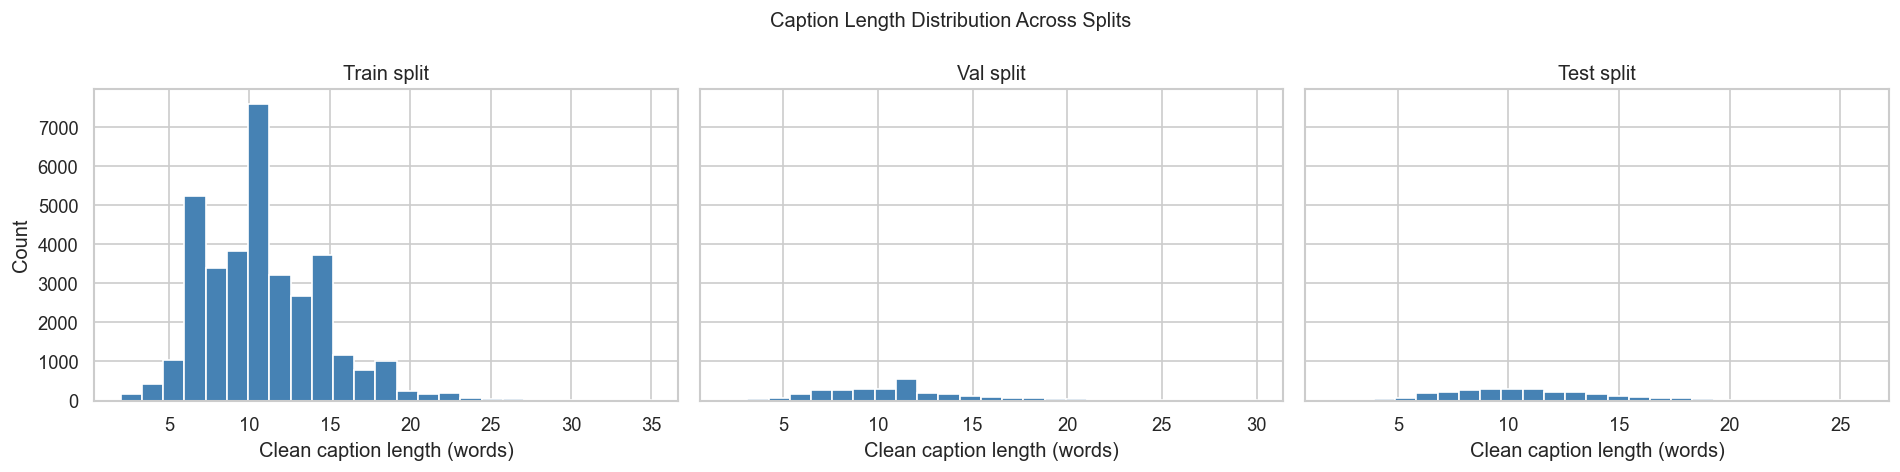

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (name, split) in zip(axes, [("Train", df_train), ("Val", df_val), ("Test", df_test)]):
    ax.hist(split["clean_word_count"], bins=25, edgecolor="white", color="steelblue")
    ax.set_title(f"{name} split")
    ax.set_xlabel("Clean caption length (words)")
axes[0].set_ylabel("Count")
plt.suptitle("Caption Length Distribution Across Splits", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Save Prepared Data

Saved files:
- `train.csv`, `val.csv`, `test.csv` — cleaned captions with split labels
- `all_cleaned.csv` — full cleaned dataset
- `split_image_names.json` — image name lists per split (convenient for DataLoader)

In [77]:
# Select columns to save
SAVE_COLS = ["image", "caption", "caption_clean", "clean_word_count"]

df_train[SAVE_COLS].to_csv(OUTPUT_DIR / "train.csv", index=False)
df_val  [SAVE_COLS].to_csv(OUTPUT_DIR / "val.csv",   index=False)
df_test [SAVE_COLS].to_csv(OUTPUT_DIR / "test.csv",  index=False)
df      [SAVE_COLS].to_csv(OUTPUT_DIR / "all_cleaned.csv", index=False)

# Save image name lists for easy DataLoader construction
split_names = {
    "train" : sorted(list(train_imgs)),
    "val"   : sorted(list(val_imgs)),
    "test"  : sorted(list(test_imgs)),
}
with open(OUTPUT_DIR / "split_image_names.json", "w") as f:
    json.dump(split_names, f, indent=2)

print("Saved files:")
for p in sorted(OUTPUT_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<30s}  {size_kb:.1f} KB")

Saved files:
  all_cleaned.csv                 6072.9 KB
  split_image_names.json          267.0 KB
  test.csv                        407.6 KB
  train.csv                       5251.3 KB
  val.csv                         414.1 KB


## 8. Summary

What was done in this notebook:

In [78]:
summary = {
    "Total images"                   : df["image"].nunique(),
    "Total captions (cleaned)"       : len(df),
    "Captions per image"             : 5,
    "Avg caption length (words)"     : round(df["clean_word_count"].mean(), 2),
    "Max caption length (words)"     : int(df["clean_word_count"].max()),
    "Unique words (cleaned)"         : len(clean_word_freq),
    "Train images"                   : len(train_imgs),
    "Val images"                     : len(val_imgs),
    "Test images"                    : len(test_imgs),
    "Tokenization done"              : False,
    "Feature extraction done"        : False,
}

print("═" * 45)
print("  PREPARATION SUMMARY")
print("═" * 45)
for k, v in summary.items():
    print(f"  {k:<35s}: {v}")
print("═" * 45)
print("\nNext step → modelling notebook:")
print("  • Build vocabulary from train.csv")
print("  • Tokenize captions")
print("  • Extract CNN features and save as .npy / .h5")
print("  • Build PyTorch Dataset and DataLoader")
print("  • Train CNN+RNN captioning model")

═════════════════════════════════════════════
  PREPARATION SUMMARY
═════════════════════════════════════════════
  Total images                       : 8091
  Total captions (cleaned)           : 40443
  Captions per image                 : 5
  Avg caption length (words)         : 10.79
  Max caption length (words)         : 35
  Unique words (cleaned)             : 8783
  Train images                       : 7000
  Val images                         : 550
  Test images                        : 541
  Tokenization done                  : False
  Feature extraction done            : False
═════════════════════════════════════════════

Next step → modelling notebook:
  • Build vocabulary from train.csv
  • Tokenize captions
  • Extract CNN features and save as .npy / .h5
  • Build PyTorch Dataset and DataLoader
  • Train CNN+RNN captioning model
